## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
import pickle
from sklearn.model_selection import train_test_split

## Load cleaned data

In [2]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)

In [3]:
data

,participant_id,session_id,task_name,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,...,range_ratio_intensity_db,std_hnr_db,stoi,pesq,si_sdr,Voice Disorders,Neurological and Neurodegenerative Disorders,Mood and Psychiatric Disorders,Respiratory Disorders,participant_id_int
0,004d42e9,07031CC3,Animal-fluency,30.849073,0.205649,26.938833,32.299248,36.319099,9.380266,321.246490,...,2.522056,6.754861,0.594471,1.159233,-14.364435,0,1,1,0,0
26,004d42e9,07031CC3,Productive-Vocabulary-1,34.447186,0.057132,32.960548,33.506256,36.057877,3.097328,100.624840,...,2.078612,7.996467,0.802794,1.277508,-0.301972,0,1,1,0,0
27,004d42e9,07031CC3,Productive-Vocabulary-2,35.895359,0.092448,33.253757,35.642937,37.830379,4.576622,381.294708,...,1.813655,7.262162,0.742845,1.199748,-1.893810,0,1,1,0,0
28,004d42e9,07031CC3,Productive-Vocabulary-3,35.248405,0.101374,33.987968,36.224056,37.653236,3.665268,85.709679,...,2.088298,7.535089,0.705393,1.185849,-3.215629,0,1,1,0,0
29,004d42e9,07031CC3,Productive-Vocabulary-4,33.798946,0.114689,32.843185,34.022396,36.028976,3.185791,158.320511,...,1.864071,6.776752,0.818446,1.240876,-1.725452,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19245,ff75b163,6A3E7090,Diadochokinesis-TA,26.530842,0.038758,25.860199,26.675362,27.344505,1.484306,28.920113,...,2.304262,4.338372,0.993067,3.620620,25.058619,1,0,0,0,441
19246,ff75b163,6A3E7090,Diadochokinesis-buttercup,27.925495,0.054326,27.288794,28.198372,28.900181,1.611387,76.308060,...,2.489648,2.995060,0.943791,2.379631,17.349405,1,0,0,0,441
19247,ff75b163,6A3E7090,Free-Speech,25.366678,0.090976,23.924431,25.256680,26.426678,2.502247,136.878525,...,2.359750,4.772076,0.898831,1.960933,12.243779,1,0,0,0,441
19249,ff75b163,6A3E7090,Free-speech-2,26.703327,0.166226,24.957359,26.008017,27.915869,2.958509,188.426971,...,2.459517,6.370732,0.869760,1.683203,6.723745,1,0,0,0,441


In [4]:
groups

array([  0,   0,   0, ..., 441, 441, 441], shape=(19238,))

## Reshape data

In [10]:
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]


y_voice = data["Voice Disorders"].copy().to_numpy()
y_neuro = data["Neurological and Neurodegenerative Disorders"].copy().to_numpy()
y_psych = data["Mood and Psychiatric Disorders"].copy().to_numpy()
y_resp = data["Respiratory Disorders"].copy().to_numpy()
X = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).to_numpy()

In [11]:
X.shape

(19238, 96)

In [12]:
y_voice.shape

(19238,)

## Split test data off

In [13]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds

In [14]:
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

## Hyperparameter tuning for random forest model

#### Voice disorders

In [15]:
# Run GridSearchCV only for Voice disorder and visualize all combinations' train vs validation performance
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grid_search(param_grid:dict, X, y, groups, label:str, n_splits:int=10):
    base_rf = RandomForestClassifier(random_state=42)

    gkf = GroupKFold(n_splits=n_splits)

    gscv = GridSearchCV(base_rf, param_grid, scoring='f1_weighted', cv=gkf, n_jobs=-1, refit=True, return_train_score=True)
    gscv.fit(X, y, groups=groups)

    # Convert cv_results_ into a DataFrame for easier analysis
    cv_res = pd.DataFrame(gscv.cv_results_)
    # keep only relevant cols
    cols = ['params','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score']
    summary_grid = cv_res[cols].sort_values('rank_test_score').reset_index(drop=True)

    print('Top 5 hyperparameter combinations (by validation rank):')
    for i, row in summary_grid.head(5).iterrows():
        print(f"Rank {int(row['rank_test_score'])}: val={row['mean_test_score']:.4f}, train={row['mean_train_score']:.4f}, params={row['params']}")

    # Scatter plot: train vs validation for every combo
    fig, ax = plt.subplots(figsize=(8,6))
    x = summary_grid['mean_train_score']
    y = summary_grid['mean_test_score']
    sc = ax.scatter(x, y, c=summary_grid['rank_test_score'], cmap='viridis', s=60, edgecolor='k')
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=1)  # reference line where train==val
    ax.set_xlabel('Mean Train F1 (CV)')
    ax.set_ylabel('Mean Validation F1 (CV)')
    ax.set_title('Train vs Validation F1 for all hyperparameter combinations (Voice)')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Rank (lower is better)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot the overfitting gap (train - val) sorted by rank
    summary_grid['train_minus_val'] = summary_grid['mean_train_score'] - summary_grid['mean_test_score']
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(len(summary_grid)), summary_grid['train_minus_val'], color='C1')
    ax.set_xlabel('Hyperparameter combination (sorted by validation rank)')
    ax.set_ylabel('Train F1 - Validation F1')
    ax.set_title('Overfitting gap per hyperparameter combination (Voice)')
    plt.tight_layout()
    plt.show()

    # Evaluate best estimator on held-out test set and show report
    best = gscv.best_estimator_

    # Save results to a dict for later use
    grid_search_results = {'cv_results_df': summary_grid, 'best_params': gscv.best_params_, 'best_score_cv': gscv.best_score_, 'best_estimator': best}
    return grid_search_results


Top 5 hyperparameter combinations (by validation rank):
Rank 1: val=0.6342, train=0.6447, params={'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
Rank 1: val=0.6342, train=0.6447, params={'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Rank 1: val=0.6342, train=0.6447, params={'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Rank 1: val=0.6342, train=0.6447, params={'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Rank 1: val=0.6342, train=0.6447, params={'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


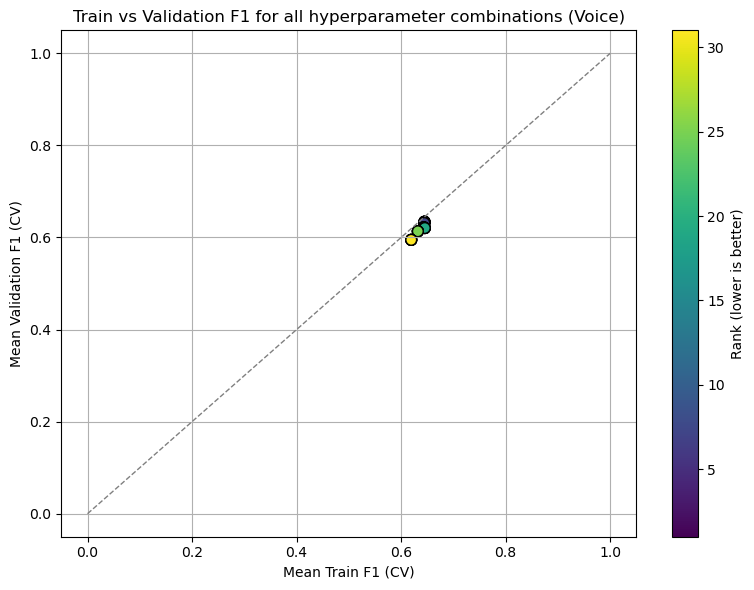

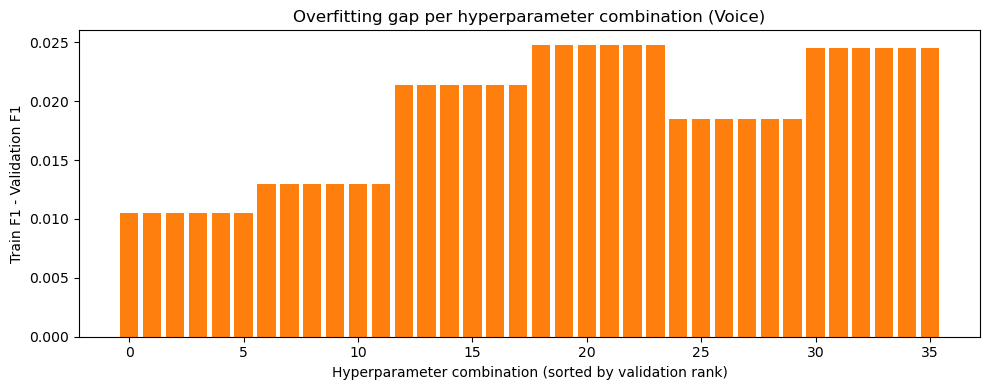

In [16]:
# Recommended parameter grid for DecisionTreeClassifier (covers regularization and split options)
param_grid = {
    'n_estimators': [5, 50, 100],
    "max_depth": [2],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 5],
    'max_features': ['sqrt', int(X_train.shape[1]*0.5)],
}

grid_search_voice = grid_search(param_grid, X_train, y_train, groups[train_idx], "Voice")

### Let's do a final test with the best hyperparameter combination.

In [17]:
top_params = {'max_depth': 2, 'max_features': 48, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}

In [18]:
gkf = GroupKFold(n_splits=7,shuffle=False)
fold_results = []

clf = RandomForestClassifier(random_state=42, **top_params)

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    clf.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = clf.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
rf_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
rf_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,13909,2310,0.642120,0.643671,"[5, 6, 33, 34, 45, 46, 47, 48, 49, 55, 56, 70,..."
1,1,13901,2318,0.650398,0.591306,"[23, 24, 28, 29, 30, 31, 32, 34, 35, 36, 38, 3..."
2,2,13901,2318,0.648402,0.622105,"[0, 16, 17, 18, 19, 20, 25, 26, 27, 50, 51, 52..."
3,3,13903,2316,0.650690,0.603174,"[1, 2, 3, 7, 8, 13, 14, 17, 18, 20, 21, 24, 25..."
4,4,13895,2324,0.642673,0.655057,"[1, 6, 7, 10, 11, 12, 15, 27, 28, 41, 42, 44, ..."
5,5,13902,2317,0.642638,0.654391,"[1, 9, 10, 12, 13, 14, 15, 21, 22, 28, 29, 32,..."
6,6,13903,2316,0.631597,0.640297,"[1, 2, 3, 4, 5, 8, 9, 15, 16, 22, 23, 36, 37, ..."


In [19]:
# final eval
y_test_preds = clf.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.62


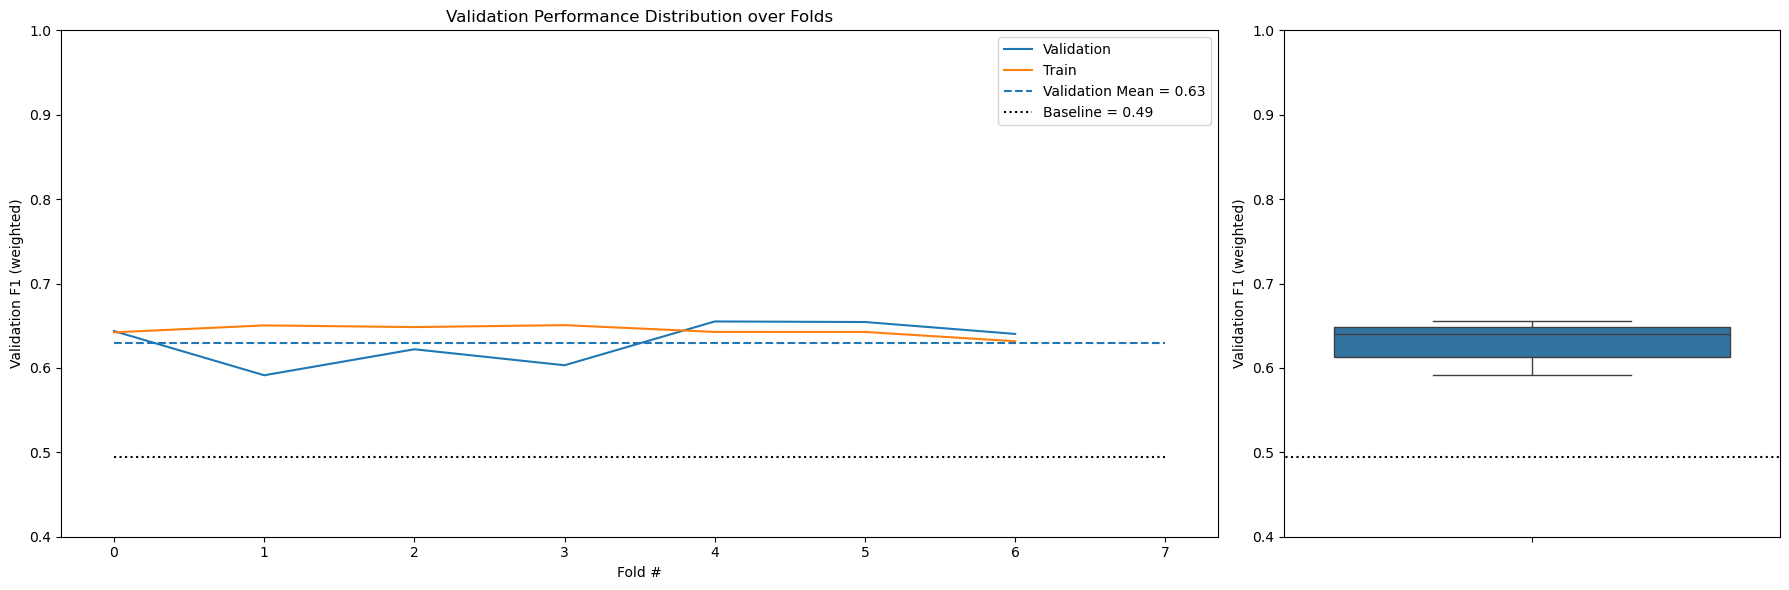

In [20]:
import seaborn as sns

val_mean = rf_gkf_fold_results["val_f1"].mean()
baseline_mean = y_voice.mean()

fig,axes = plt.subplots(1,2,figsize=(18,6),width_ratios=[0.7,0.3])

sns.lineplot(data=rf_gkf_fold_results,x="fold",y="val_f1",ax=axes[0],label="Validation")
sns.lineplot(data=rf_gkf_fold_results,x="fold",y="train_f1",ax=axes[0],label="Train")
axes[0].plot([0,7],[val_mean, val_mean], ls="--",c="tab:blue",label=f"Validation Mean = {np.round(val_mean, 2)}")
axes[0].plot([0,7],[baseline_mean, baseline_mean], ls="dotted",c="k",label=f"Baseline = {np.round(baseline_mean, 2)}")
axes[0].set_ylim([0.4, 1.0])
axes[0].set_ylabel("Validation F1 (weighted)")
axes[0].set_xlabel("Fold #")
axes[0].legend()
axes[0].set_title("Validation Performance Distribution over Folds")

sns.boxplot(data=rf_gkf_fold_results, y="val_f1",ax=axes[1])
axes[1].plot([-1,2], [baseline_mean, baseline_mean], ls="dotted", c="k")
axes[1].set_ylim([0.4, 1.0])
axes[1].set_ylabel("Validation F1 (weighted)")
axes[1].set_xlim([-0.5, 0.5])
plt.tight_layout()
plt.show()

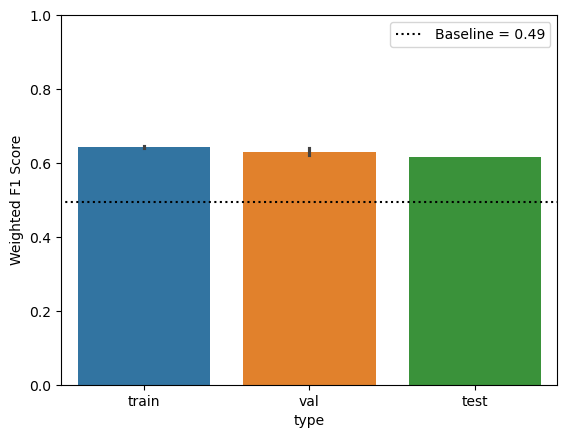

In [21]:
train_f1 = rf_gkf_fold_results["train_f1"].mean()
val_f1 = rf_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in rf_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.plot([-1,3], [baseline_mean, baseline_mean], ls="dotted", c="k", label=f"Baseline = {np.round(baseline_mean,2)}")
plt.ylabel("Weighted F1 Score")
plt.legend()
plt.ylim([0, 1.0])
plt.xlim([-0.5,2.5])
plt.show()

In [22]:
# save model
import pickle
filepath = 'models/random-forest-trained.pkl'
with open(filepath, 'wb') as file:
    pickle.dump(clf, file)